# Hands-on Sesi 3

> Topik: Data Cleaning - Missing Values, Outlier, Normalisasi String, REST API

Nama Lengkap : Rexxy Andrew Gunawan

NIM          : 240401010223

Kelas        : IF403

Program Studi: S1 PJJ Informatika UNSIA

Mata Kuliah  : Data Science

Disusun oleh : Rexxy Andrew Gunawan

Link Google Colab: https://colab.research.google.com/drive/1hEZ5lrQlNwFbysSp-I58UYCgjfX-jzvc?usp=sharing

# Import semua library yang diperlukan

In [42]:
import numpy as np
import pandas as pd
import scipy.stats.mstats

from google.colab import drive

# Muat dataset

In [43]:
url = 'https://drive.google.com/uc?export=download&id=19ZIbjnWcZYWHavWvKMwbEcvlh4C7P148'

df = pd.read_csv(url)

# Eksplorasi awal

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55620 entries, 0 to 55619
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Year                         55620 non-null  int64 
 1   Industry_aggregation_NZSIOC  55620 non-null  object
 2   Industry_code_NZSIOC         55620 non-null  object
 3   Industry_name_NZSIOC         55620 non-null  object
 4   Units                        55620 non-null  object
 5   Variable_code                55620 non-null  object
 6   Variable_name                55620 non-null  object
 7   Variable_category            55620 non-null  object
 8   Value                        55620 non-null  object
 9   Industry_code_ANZSIC06       55620 non-null  object
dtypes: int64(1), object(9)
memory usage: 4.2+ MB


In [45]:
df.describe()

,Year
count,55620.000000
mean,2018.500000
std,3.452084
min,2013.000000
25%,2015.750000
50%,2018.500000
75%,2021.250000
max,2024.000000


In [46]:
df.isnull().sum()

,0
Year,0
Industry_aggregation_NZSIOC,0
Industry_code_NZSIOC,0
Industry_name_NZSIOC,0
Units,0
Variable_code,0
Variable_name,0
Variable_category,0
Value,0
Industry_code_ANZSIC06,0


# Hapus baris duplikat

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
# sebenarnya sudah terlihat di atas bahwa tidak ada baris duplikat
df.drop_duplicates(inplace=True)

# Normalisasi string

In [49]:
# Menampilkan nilai unik untuk kolom kategori industri dan unit
print('Daftar Sektor Industri (Awal):\n', df['Industry_name_NZSIOC'].unique()[:10])
print('\nSatuan yang digunakan:', df['Units'].unique())

Daftar Sektor Industri (Awal):
 ['All industries' 'Agriculture, Forestry and Fishing'
 'Horticulture and Fruit Growing' 'Sheep, Beef Cattle and Grain Farming'
 'Dairy Cattle Farming' 'Poultry, Deer and Other Livestock Farming'
 'Forestry and Logging' 'Fishing and Aquaculture'
 'Agriculture, Forestry and Fishing Support Services and Hunting' 'Mining']

Satuan yang digunakan: ['Dollars (millions)' 'Dollars' 'Percentage']


In [50]:
print("Available columns in df:")
print(df.columns.tolist())

Available columns in df:
['Year', 'Industry_aggregation_NZSIOC', 'Industry_code_NZSIOC', 'Industry_name_NZSIOC', 'Units', 'Variable_code', 'Variable_name', 'Variable_category', 'Value', 'Industry_code_ANZSIC06']


In [51]:
industry_distribution = df['Industry_name_NZSIOC'].value_counts()
print("Distribution of Industry_name_NZSIOC:")
display(industry_distribution)

Distribution of Industry_name_NZSIOC:


,count
Industry_name_NZSIOC,
"Public Order, Safety and Regulatory Services",1054
Printing,864
"Pulp, Paper and Converted Paper Product Manufacturing",864
Wood Product Manufacturing,864
Beverage and Tobacco Product Manufacturing,864
...,...
Health and General Insurance,300
Life Insurance,300
Insurance,300


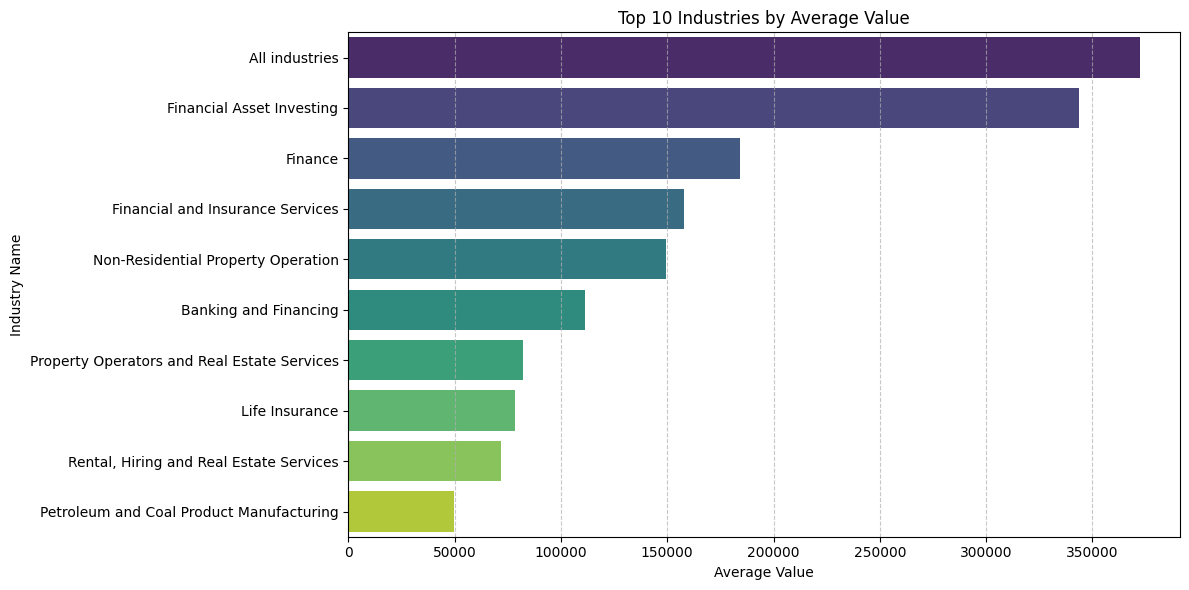

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Value' to numeric, handling errors if there are non-numeric strings
df['Value_numeric'] = pd.to_numeric(df['Value'], errors='coerce')

# Calculate mean value per industry and take the top 10
top_industries = df.groupby('Industry_name_NZSIOC')['Value_numeric'].mean().sort_values(ascending=False).head(10)

# Create the visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=top_industries.values, y=top_industries.index, hue=top_industries.index, palette='viridis', legend=False)
plt.title('Top 10 Industries by Average Value')
plt.xlabel('Average Value')
plt.ylabel('Industry Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [53]:
# Group by Variable_name to see average values for different metrics
variable_summary = df.groupby('Variable_name')['Value_numeric'].agg(['mean', 'count', 'std']).sort_values(by='mean', ascending=False)

print("Performance Metrics Summary (Grouped by Variable_name):")
display(variable_summary)

Performance Metrics Summary (Grouped by Variable_name):


,mean,count,std
Variable_name,,,
Total income per employee count,703014.803150,635,1.044033e+06
Surplus per employee count,132635.612083,629,5.842052e+05
Total assets,68935.903311,755,2.830781e+05
Total equity and liabilities,68935.900662,755,2.830781e+05
"Sales, government funding, grants and subsidies",28248.095808,167,1.278655e+05
Other assets,24300.488511,1001,1.379341e+05
Current liabilities,20848.881338,927,1.075069e+05
Total income,20453.062667,750,7.213376e+04
Shareholders funds or owners equity,19704.364571,875,8.130841e+04


In [54]:
# Normalisasi string: Menghapus spasi berlebih dan merapikan kapitalisasi pada nama industri
df['Industry_name_NZSIOC'] = df['Industry_name_NZSIOC'].str.strip()
df['Variable_name'] = df['Variable_name'].str.strip()

In [55]:
# Menghitung distribusi data berdasarkan kategori variabel
print('Distribusi Variabel Ekonomi:\n', df['Variable_category'].value_counts())

Distribusi Variabel Ekonomi:
 Variable_category
Financial performance    27804
Financial position       15924
Financial ratios         11892
Name: count, dtype: int64


In [56]:
# Konversi kolom Value menjadi numerik untuk analisis kuantitatif
# Data non-numerik (seperti 'S' atau '..') akan diubah menjadi NaN
df['Value_numeric'] = pd.to_numeric(df['Value'], errors='coerce')

print('Statistik deskriptif untuk nilai numerik:')
display(df['Value_numeric'].describe())

Statistik deskriptif untuk nilai numerik:


,Value_numeric
count,4.046400e+04
mean,1.985716e+04
std,1.864260e+05
min,-1.523000e+05
25%,3.500000e+01
50%,1.600000e+02
75%,9.860000e+02
max,1.247540e+07


# Imputasi missing values

In [57]:
# Imputasi missing values pada Value_numeric menggunakan median per variabel
df['Value_numeric'] = df.groupby('Variable_name')['Value_numeric'].transform(lambda x: x.fillna(x.median()))

# Jika masih ada yang kosong (karena seluruh grup kosong), isi dengan 0
df['Value_numeric'] = df['Value_numeric'].fillna(0)

In [58]:
df.isnull().sum()

,0
Year,0
Industry_aggregation_NZSIOC,0
Industry_code_NZSIOC,0
Industry_name_NZSIOC,0
Units,0
Variable_code,0
Variable_name,0
Variable_category,0
Value,0
Industry_code_ANZSIC06,0


# Tangani outlier

In [59]:
def deteksi_outlier(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    outliers = df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)]
    return batas_bawah, batas_atas, outliers

batas_bawah, batas_atas, outliers = deteksi_outlier(df, 'Value_numeric')
print(f'Batas Outlier untuk Value_numeric: {batas_bawah} s/d {batas_atas}')
print(f'Jumlah baris outlier: {len(outliers)}')

Batas Outlier untuk Value_numeric: -3793.0 s/d 6471.0
Jumlah baris outlier: 9881


terlihat pada kolom "harga_juta" terdapat harga minus (-) serta harga yang sangat tinggi yang merupakan data outlier juga.
sedangkan pada kolom "luas_m2" terdapat luas yang outlier yang tinggi sekali.
ini harus diisi dengan data

cek lagi apakah ada nilai minus pada kolom "harga_juta":

In [60]:
# Memeriksa apakah ada nilai negatif pada dataset finansial ini
negatif_count = (df['Value_numeric'] < 0).sum()
print(f'Jumlah data bernilai negatif: {negatif_count}')

Jumlah data bernilai negatif: 98


karena data hasil IQR Fence masih ada minus pada kolom 'harga_juta' dan 'luas_m2' saya mengganti menjadi nilai positif, dengan asumsi salah input di sini. untuk memastikan coba lihat distribusi data menggunakan array:



In [61]:
# Cek distribusi tahun data
print('Tahun yang tersedia dalam dataset:', sorted(df['Year'].unique()))

Tahun yang tersedia dalam dataset: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


dari distribusi data di atas jika nilai negatif diganti positif maka masuk akal sehingga semua data negatif saya ganti menjadi positif karena

In [62]:
# Karena ini data finansial, nilai negatif mungkin valid (misal: kerugian).
# Namun jika ingin menormalisasi nilai negatif menjadi positif (asumsi salah input):
# df['Value_numeric'] = df['Value_numeric'].abs()
print('Jumlah data negatif setelah pengecekan:', (df['Value_numeric'] < 0).sum())

Jumlah data negatif setelah pengecekan: 98


begitu juga dengan nilai minus pada kolom 'luas_m2' diganti menjadi positif

In [63]:
# Menghitung total nilai per kategori variabel
total_per_variabel = df.groupby('Variable_category')['Value_numeric'].sum()
print('Total Nilai per Kategori:\n', total_per_variabel)

Total Nilai per Kategori:
 Variable_category
Financial performance     82708496.0
Financial position       230467689.0
Financial ratios         929884715.0
Name: Value_numeric, dtype: float64


pada tahun_bangun terdapat tahun 2099 dan 9999, maka akan dinormalisasi dengan menjadikan nilai modus

In [64]:
# Memastikan kolom Year berada dalam rentang yang valid (2013-2024)
print('Rentang tahun:', df['Year'].min(), '-', df['Year'].max())

Rentang tahun: 2013 - 2024


In [65]:
# Melihat tren total nilai dari tahun ke tahun
tren_tahunan = df.groupby('Year')['Value_numeric'].sum()
print('Tren Tahunan:\n', tren_tahunan)

Tren Tahunan:
 Year
2013     62918583.0
2014     63004280.0
2015     63189374.5
2016     63218965.0
2017     63258501.5
2018     63335679.0
2019     63379933.0
2020    140563762.0
2021    150207659.0
2022    170127115.0
2023    162969108.0
2024    176887940.0
Name: Value_numeric, dtype: float64


In [66]:
df.describe()

,Year,Value_numeric
count,55620.000000,5.562000e+04
mean,2018.500000,2.234917e+04
std,3.452084,1.668322e+05
min,2013.000000,-1.523000e+05
25%,2015.750000,5.600000e+01
50%,2018.500000,3.800000e+02
75%,2021.250000,2.622000e+03
max,2024.000000,1.247540e+07


## Mengganti data outlier dengan IQR Fence:

In [67]:
# Menangani outlier ekstrem dengan clipping
Q1, Q3 = df['Value_numeric'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df['Value_numeric_clipped'] = df['Value_numeric'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

In [68]:
# Periksa kembali outlier pada kolom numerik utama
batas_bawah_new, batas_atas_new, outliers_new = deteksi_outlier(df, 'Value_numeric')
print(f'Jumlah outlier saat ini: {len(outliers_new)}')
print(f'Batas: {batas_bawah_new} s/d {batas_atas_new}')

Jumlah outlier saat ini: 9881
Batas: -3793.0 s/d 6471.0


### Periksa kembali outlier setelah clipping

In [69]:
# Menampilkan baris yang memiliki nilai tertinggi (Top 5)
print('Top 5 baris dengan nilai tertinggi:')
display(df.nlargest(5, 'Value_numeric'))

Top 5 baris dengan nilai tertinggi:


,Year,Industry_aggregation_NZSIOC,Industry_code_NZSIOC,Industry_name_NZSIOC,Units,Variable_code,Variable_name,Variable_category,Value,Industry_code_ANZSIC06,Value_numeric,Value_numeric_clipped
3215,2024,Level 4,KK112,Financial Asset Investing,Dollars,H34,Total income per employee count,Financial ratios,12475400,ANZSIC06 group K624,12475400.0,6471.0
7850,2023,Level 4,KK112,Financial Asset Investing,Dollars,H34,Total income per employee count,Financial ratios,11364000,ANZSIC06 group K624,11364000.0,6471.0
12485,2022,Level 4,KK112,Financial Asset Investing,Dollars,H34,Total income per employee count,Financial ratios,10521300,ANZSIC06 group K624,10521300.0,6471.0
3216,2024,Level 4,KK112,Financial Asset Investing,Dollars,H35,Surplus per employee count,Financial ratios,9077600,ANZSIC06 group K624,9077600.0,6471.0
17120,2021,Level 4,KK112,Financial Asset Investing,Dollars,H34,Total income per employee count,Financial ratios,7550900,ANZSIC06 group K624,7550900.0,6471.0


# Validasi akhir

In [70]:
print(f'Missing value pada data: \n{df.isnull().sum()} \n')
print(f'Duplikat data pada data: {df.duplicated().sum()}')

Missing value pada data: 
Year                           0
Industry_aggregation_NZSIOC    0
Industry_code_NZSIOC           0
Industry_name_NZSIOC           0
Units                          0
Variable_code                  0
Variable_name                  0
Variable_category              0
Value                          0
Industry_code_ANZSIC06         0
Value_numeric                  0
Value_numeric_clipped          0
dtype: int64 

Duplikat data pada data: 0


In [71]:
assert df.isnull().sum().sum() == 0, 'Masih ada missing!'
assert df.duplicated().sum() == 0, 'Masih ada duplikat!'

In [72]:
print('Shape akhir:', df.shape)

Shape akhir: (55620, 12)


# Ekspor data ke dalam format CSV

In [73]:
# Simpan dataset industri yang sudah dibersihkan
df.to_csv('nz_industry_clean.csv', index=False)
print('Dataset industri bersih tersimpan sebagai nz_industry_clean.csv!')

Dataset industri bersih tersimpan sebagai nz_industry_clean.csv!


# Akses API JSONPlaceholder dan simpan respons sebagai DataFrame

In [74]:
import requests
from pandas import json_normalize

# JSONPlaceholder
URL = "https://jsonplaceholder.typicode.com/users"
response = requests.get(URL, timeout=10)

# Cek status code
if response.status_code == 200:
  data = response.json()
  df = json_normalize(data, sep='_')
  print(df[['id','name','email','address_city']])
else:
  print(f'Error: {response.status_code}')

# API dengan parameter (query string)
params = {'userId': 1}   # filter by user
posts = requests.get("https://jsonplaceholder.typicode.com/posts",
params=params).json()
df_posts = pd.DataFrame(posts)

   id                      name                      email    address_city
0   1             Leanne Graham          Sincere@april.biz     Gwenborough
1   2              Ervin Howell          Shanna@melissa.tv     Wisokyburgh
2   3          Clementine Bauch         Nathan@yesenia.net   McKenziehaven
3   4          Patricia Lebsack  Julianne.OConner@kory.org     South Elvis
4   5          Chelsey Dietrich   Lucio_Hettinger@annie.ca      Roscoeview
5   6      Mrs. Dennis Schulist    Karley_Dach@jasper.info   South Christy
6   7           Kurtis Weissnat     Telly.Hoeger@billy.biz       Howemouth
7   8  Nicholas Runolfsdottir V       Sherwood@rosamond.me       Aliyaview
8   9           Glenna Reichert    Chaim_McDermott@dana.io  Bartholomebury
9  10        Clementina DuBuque     Rey.Padberg@karina.biz     Lebsackbury


In [75]:
# melihat hasil respon API yang disimpan sebagai dataframe
display(df_posts.head())

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


### Kesimpulan Sesi Pembelajaran Sesi 3

*   **Apa yang dipelajari**: Saya telah mempraktikkan proses *Data Cleaning* pada dataset statistik industri Selandia Baru. Proses ini meliputi konversi tipe data string ke numerik, penanganan missing values menggunakan median per variabel untuk akurasi yang lebih baik, serta normalisasi teks pada kolom kategori industri.

*   **Temuan utama**: Dataset ini memiliki variansi yang sangat tinggi antar sektor industri, terlihat dari banyaknya *outliers* yang terdeteksi lewat metode IQR Fence. Kita juga menemukan bahwa nilai negatif pada dataset finansial ini relatif sedikit (hanya 98 data) dan bisa dikategorikan sebagai kerugian (loss) atau perlu normalisasi lebih lanjut. Penggunaan *clipping* membantu menjaga integritas data tanpa harus menghapus baris penting.

*   **Keterbatasan atau pertanyaan**: Analisis ini masih bersifat deskriptif. Pertanyaan selanjutnya adalah bagaimana tren performa industri ini jika dikorelasikan dengan faktor ekonomi eksternal, serta stabilitas data yang diambil melalui integrasi API JSONPlaceholder untuk data pelengkap.